# Netflix Content Analysis — Visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

df         = pd.read_csv('../data/processed/netflix_clean.csv', parse_dates=['date_added'])
df_genres  = pd.read_csv('../data/processed/netflix_genres.csv')
df_country = pd.read_csv('../data/processed/netflix_country.csv')

ACCENT = '#E50914'
DARK   = '#221F1F'

plt.rcParams.update({
    'figure.figsize'  : (12, 6),
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.titlesize'  : 15,
    'axes.titleweight': 'bold',
    'axes.titlepad'   : 15,
    'axes.labelsize'  : 12,
    'savefig.dpi'     : 150,
    'savefig.bbox'    : 'tight',
})

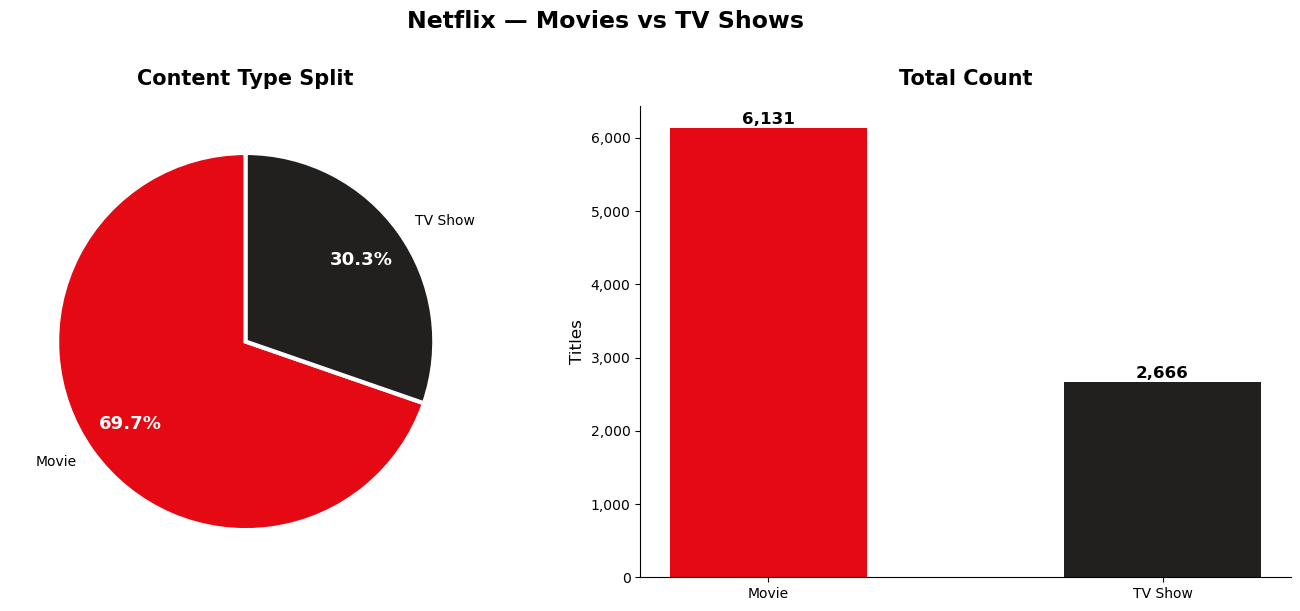

In [2]:
# chart 1 — movies vs tv shows
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

wedges, texts, autotexts = axes[0].pie(
    type_counts, labels=type_counts.index, autopct='%1.1f%%',
    colors=[ACCENT, DARK], startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3}
)
for t in autotexts:
    t.set_color('white'); t.set_fontsize(13); t.set_fontweight('bold')
axes[0].set_title('Content Type Split')

bars = axes[1].bar(type_counts.index, type_counts.values, color=[ACCENT, DARK], edgecolor='none', width=0.5)
for bar, val in zip(bars, type_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Total Count')
axes[1].set_ylabel('Titles')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Netflix — Movies vs TV Shows', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../plots/01_content_type.png')
plt.show()

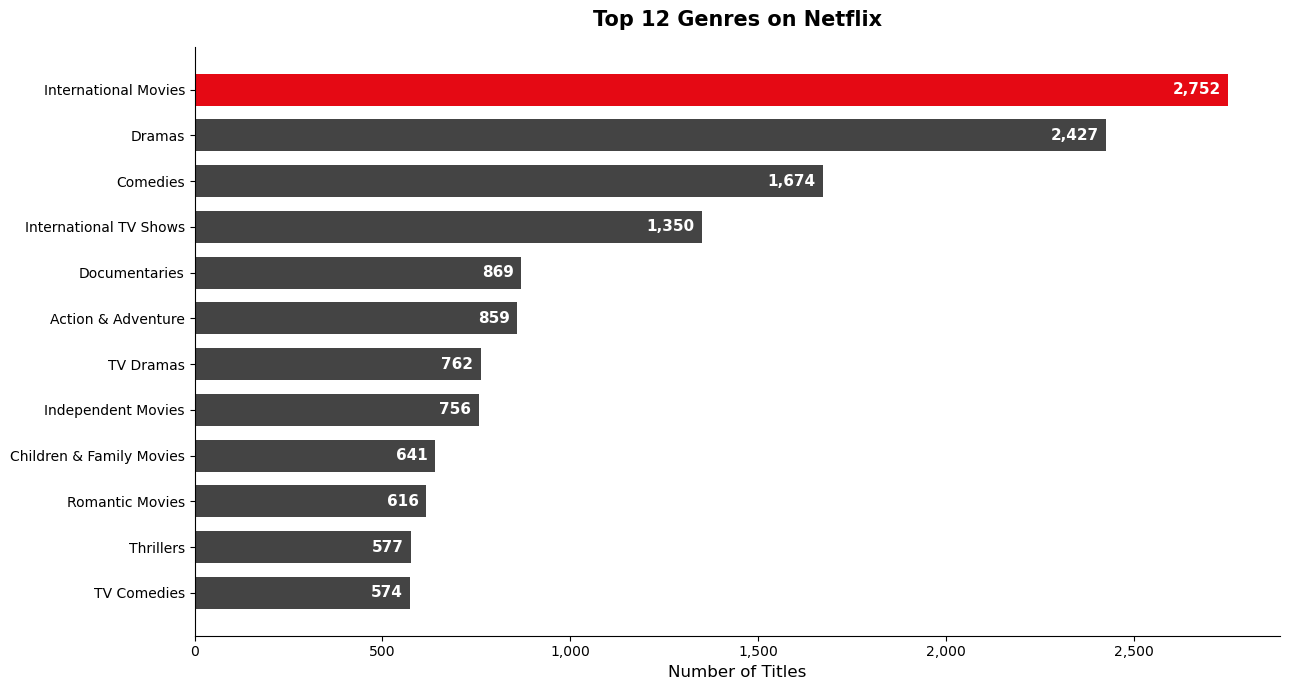

In [3]:
# chart 2 — top genres
top_genres = df_genres['listed_in'].value_counts().head(12)
colors_bar = [ACCENT if i == 0 else '#444' for i in range(len(top_genres))]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1], color=colors_bar[::-1], edgecolor='none', height=0.7)
for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(bar.get_width() - 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='right', color='white', fontweight='bold', fontsize=11)
ax.set_title('Top 12 Genres on Netflix')
ax.set_xlabel('Number of Titles')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('../plots/02_top_genres.png')
plt.show()

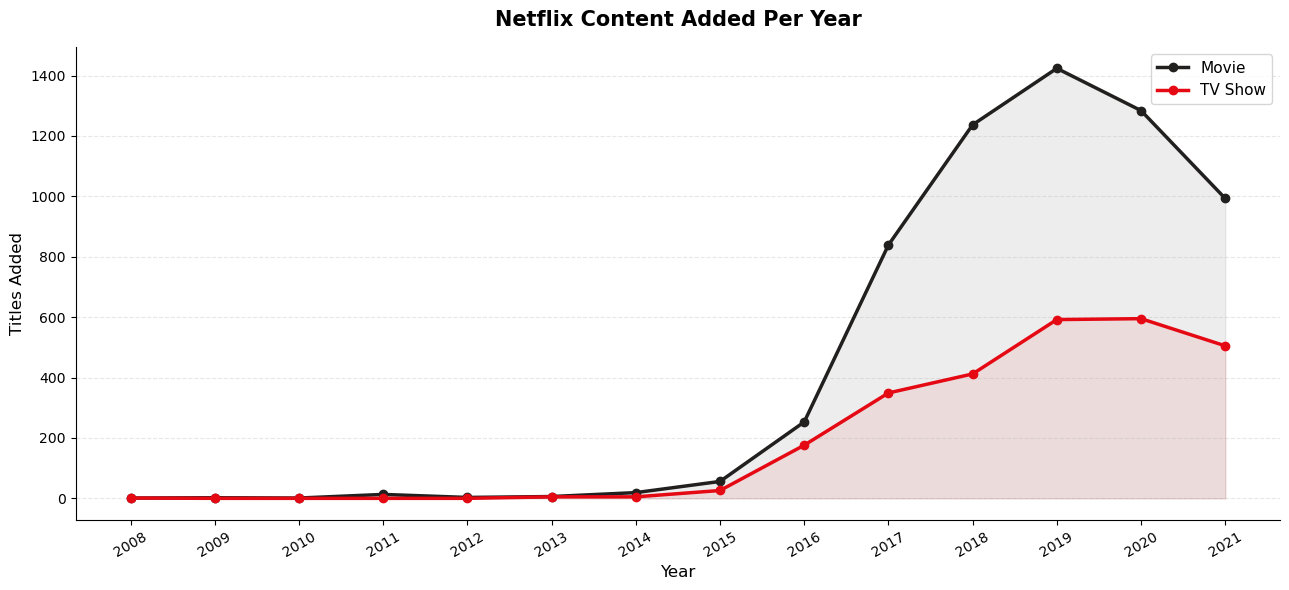

In [4]:
# chart 3 — content added over time
type_yearly = df.groupby(['year_added', 'type'])['show_id'].count().unstack().fillna(0)

fig, ax = plt.subplots(figsize=(13, 6))
for col, color in zip(type_yearly.columns, [DARK, ACCENT]):
    ax.plot(type_yearly.index, type_yearly[col], color=color, linewidth=2.5, marker='o', markersize=6, label=col)
    ax.fill_between(type_yearly.index, type_yearly[col], alpha=0.08, color=color)
ax.set_title('Netflix Content Added Per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Titles Added')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xticks(type_yearly.index)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../plots/03_content_over_time.png')
plt.show()

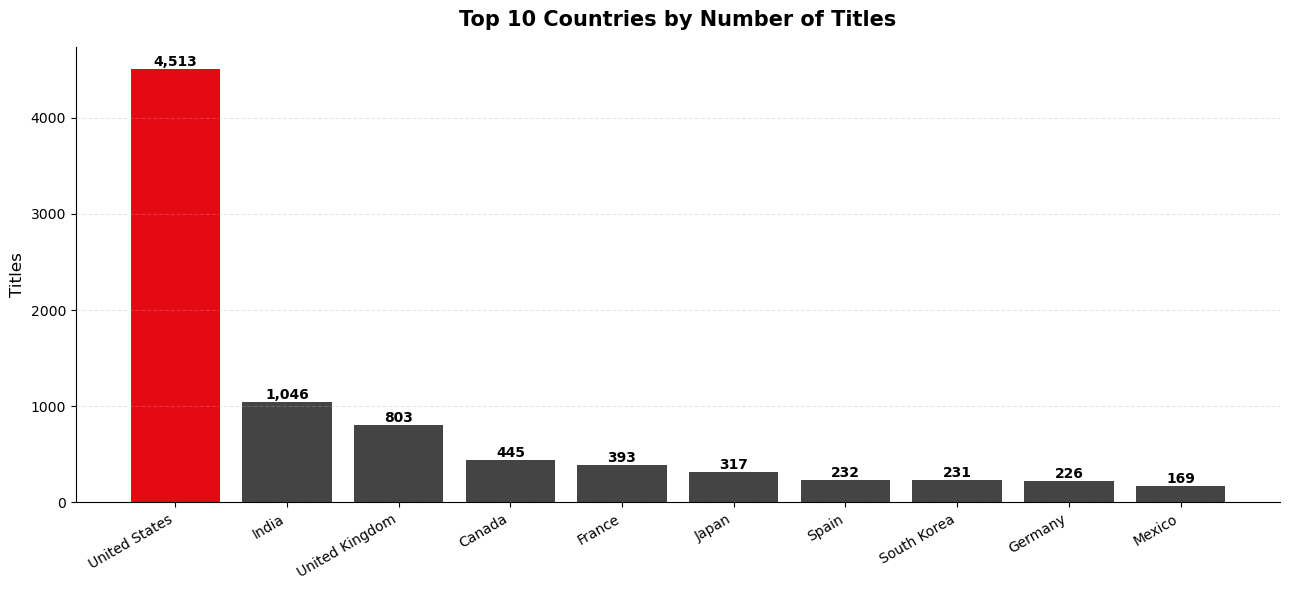

In [5]:
# chart 4 — top countries
top_countries = df_country['country'].value_counts().head(10)
colors_bar = [ACCENT if i == 0 else '#444' for i in range(len(top_countries))]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(range(len(top_countries)), top_countries.values, color=colors_bar, edgecolor='none')
for i, (c, val) in enumerate(zip(top_countries.index, top_countries.values)):
    ax.text(i, val + 30, f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(top_countries)))
ax.set_xticklabels(top_countries.index, rotation=30, ha='right', fontsize=10)
ax.set_title('Top 10 Countries by Number of Titles')
ax.set_ylabel('Titles')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../plots/04_top_countries.png')
plt.show()

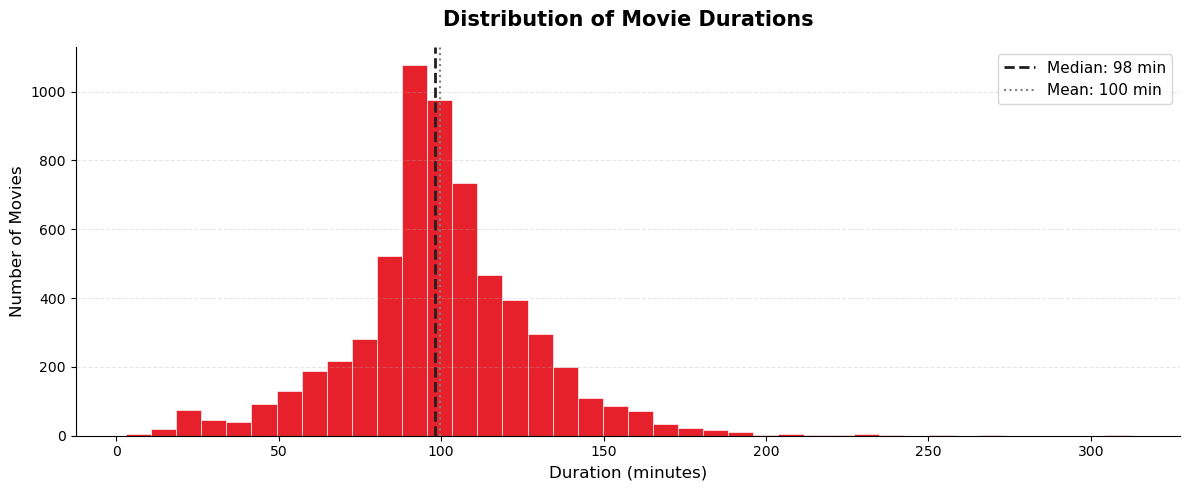

In [6]:
# chart 5 — movie duration histogram
movie_dur = df[df['type'] == 'Movie']['duration_mins'].dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(movie_dur, bins=40, color=ACCENT, edgecolor='white', linewidth=0.5, alpha=0.9)
ax.axvline(movie_dur.median(), color=DARK, linestyle='--', linewidth=2, label=f'Median: {movie_dur.median():.0f} min')
ax.axvline(movie_dur.mean(),   color='gray', linestyle=':', linewidth=1.5, label=f'Mean: {movie_dur.mean():.0f} min')
ax.set_title('Distribution of Movie Durations')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Number of Movies')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../plots/05_movie_durations.png')
plt.show()

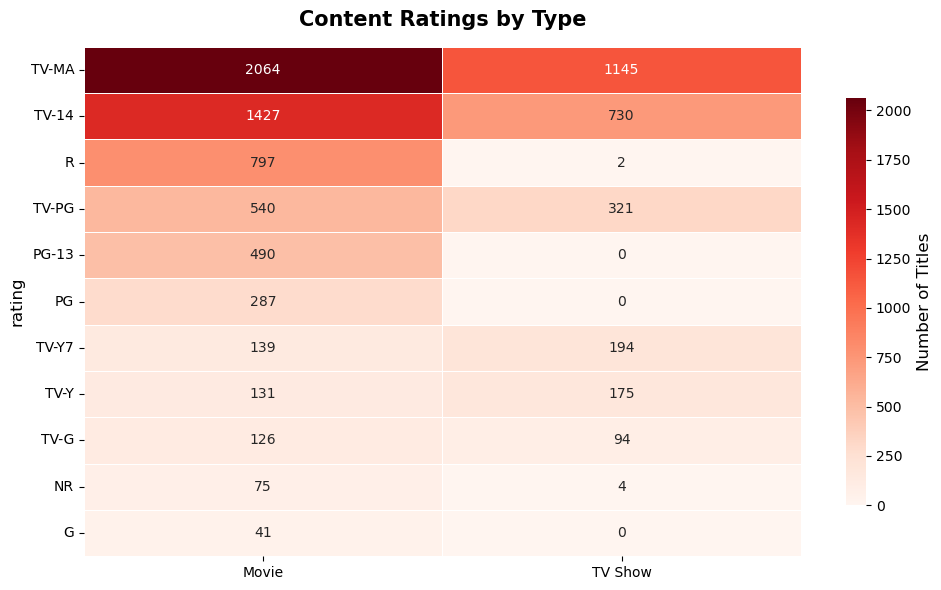

In [7]:
# chart 6 — ratings heatmap
rating_type = df.groupby(['rating', 'type'])['show_id'].count().unstack().fillna(0)
rating_type = rating_type[rating_type.sum(axis=1) > 10].sort_values(by=rating_type.columns[0], ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(rating_type, annot=True, fmt='.0f', cmap='Reds',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Number of Titles', 'shrink': 0.8})
ax.set_title('Content Ratings by Type')
ax.set_xlabel('')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('../plots/06_ratings_heatmap.png')
plt.show()

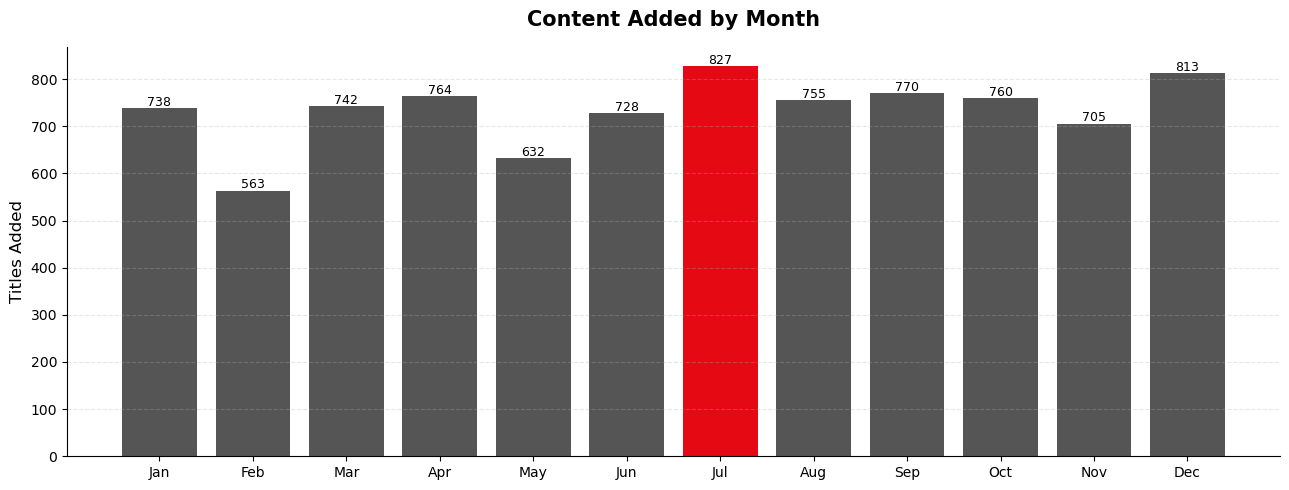

All 7 charts saved to plots/


In [8]:
# chart 7 — monthly additions
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('month_name')['show_id'].count().reindex(month_order)
peak = monthly.idxmax()

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(month_order, monthly.values,
              color=[ACCENT if m == peak else '#555' for m in month_order], edgecolor='none')
for bar, val in zip(bars, monthly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:,}', ha='center', fontsize=9)
ax.set_title('Content Added by Month')
ax.set_ylabel('Titles Added')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../plots/07_monthly_additions.png')
plt.show()
print('All 7 charts saved to plots/')